download cifar10 dataset

In [69]:
import numpy as np
from numpy import ndarray
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
from matplotlib import pyplot as plt
import keras
from tensorflow.keras.utils import plot_model

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

assumptions about the dataset

In [70]:
num_of_classes = 10

evaluate input data

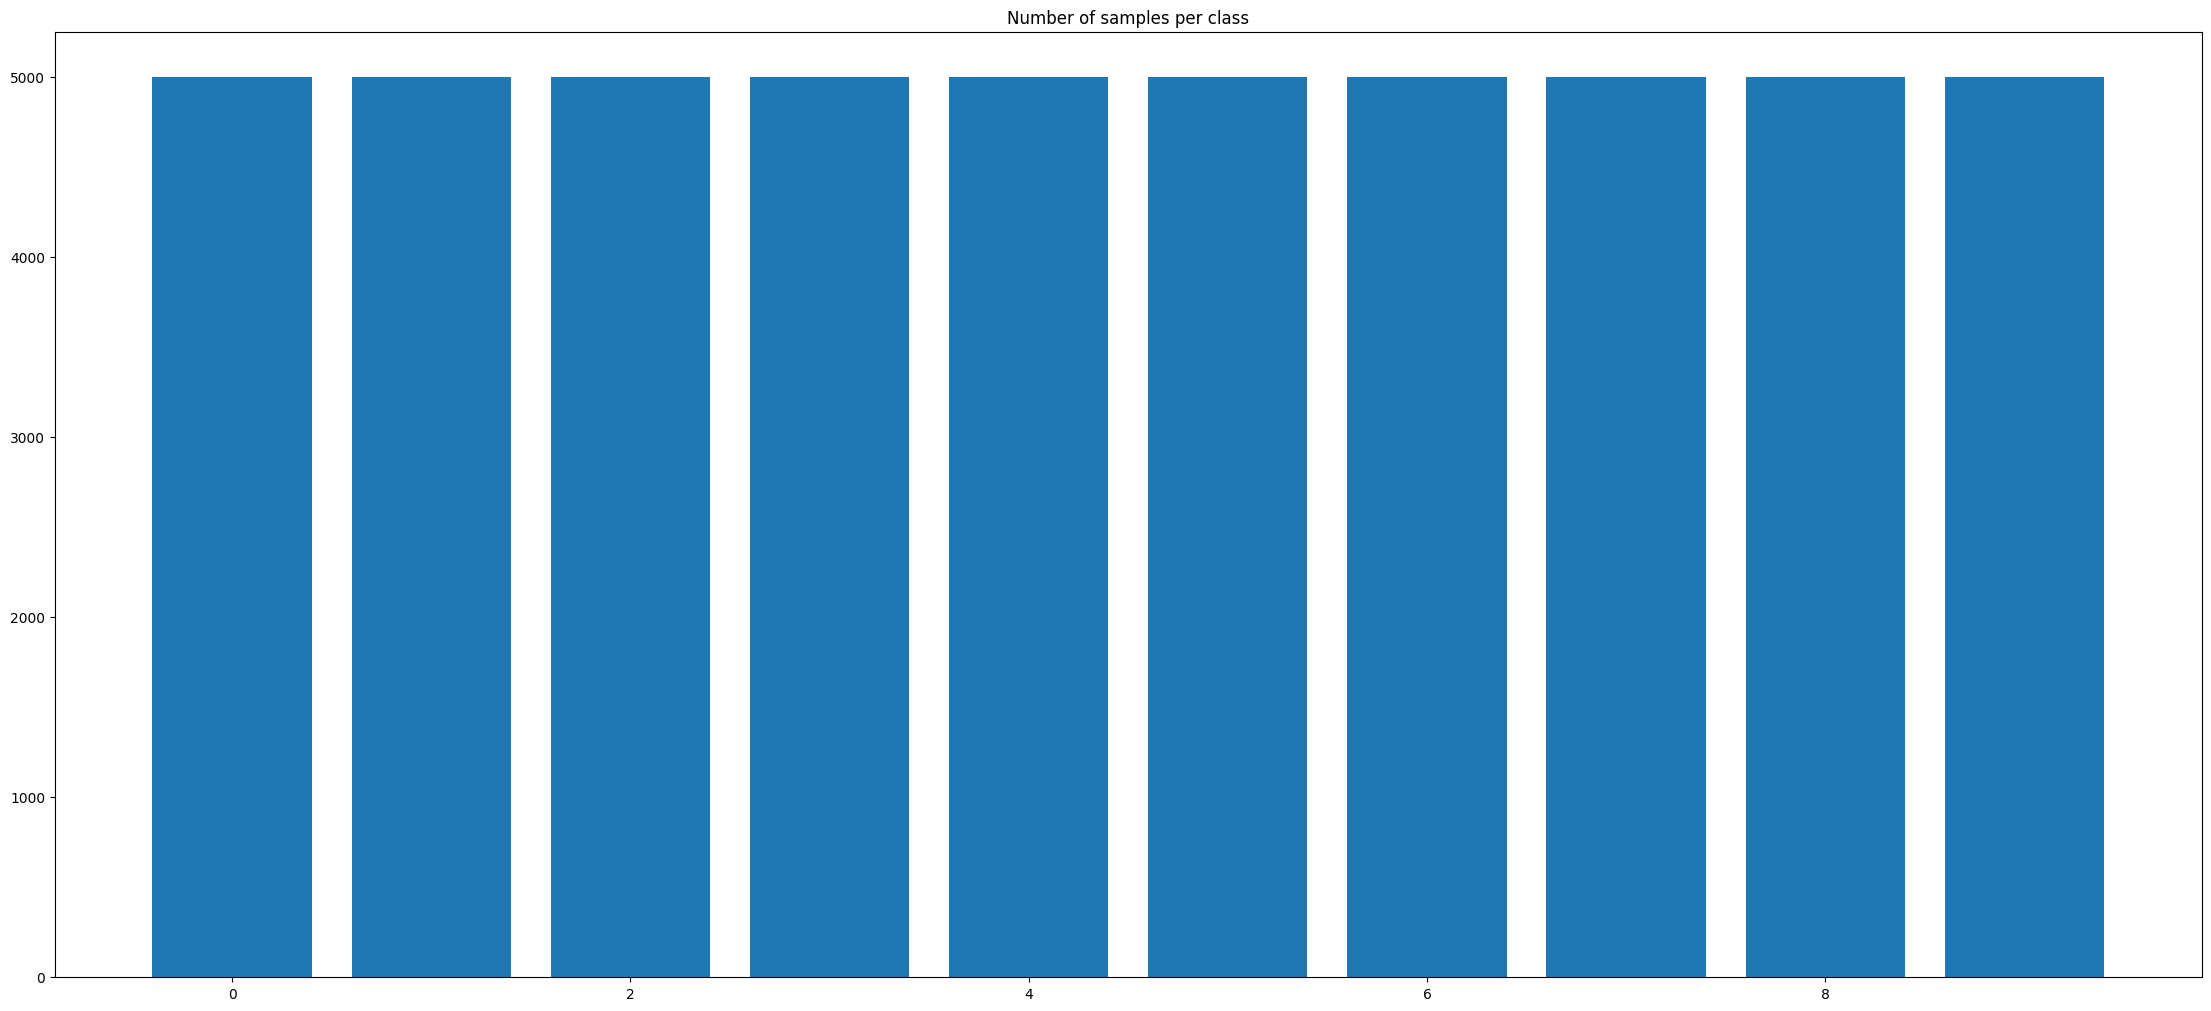

In [71]:
count_of_samples = {}

assert 0 == len(y_train[y_train == None])
assert 0 == len(y_test[y_test == None])

assert False == np.isnan(x_train).any()
assert False == np.isnan(x_test).any()

for label in range(0,num_of_classes):
    count_of_samples[label] = len(y_train[y_train == label])


fig, axes = plt.subplots(1, 1, figsize=(22, 10), constrained_layout=True)

axes.bar(count_of_samples.keys(), count_of_samples.values())
axes.set_title("Number of samples per class")

plt.show()

normalize features data

In [72]:
def normalize_image_data(data_set: ndarray) -> np.ndarray:
    normalized = data_set.copy()
    print(f"shape before : {normalized.shape}")
    normalized.reshape(data_set.shape[0], data_set.shape[1], data_set.shape[2], 3)
    print(f"shape after : {normalized.shape}")
    return normalized / 255

x_train = normalize_image_data(x_train)
x_test = normalize_image_data(x_test)

shape before : (50000, 32, 32, 3)
shape after : (50000, 32, 32, 3)
shape before : (10000, 32, 32, 3)
shape after : (10000, 32, 32, 3)


format label data

In [78]:
def format_label_data(data_set: ndarray) -> ndarray:
    formatted = data_set.copy()
    print(f"shape before : {formatted.shape}")
    formatted = np.asarray([tf.one_hot(e.astype(np.int32), depth=10) for e in formatted])
    print(f"shape after : {formatted.shape}")
    return formatted

y_train = format_label_data(y_train)
y_test = format_label_data(y_test)

assert 10 == y_train.shape[2]
assert 10 == y_test.shape[2]

build classifier model

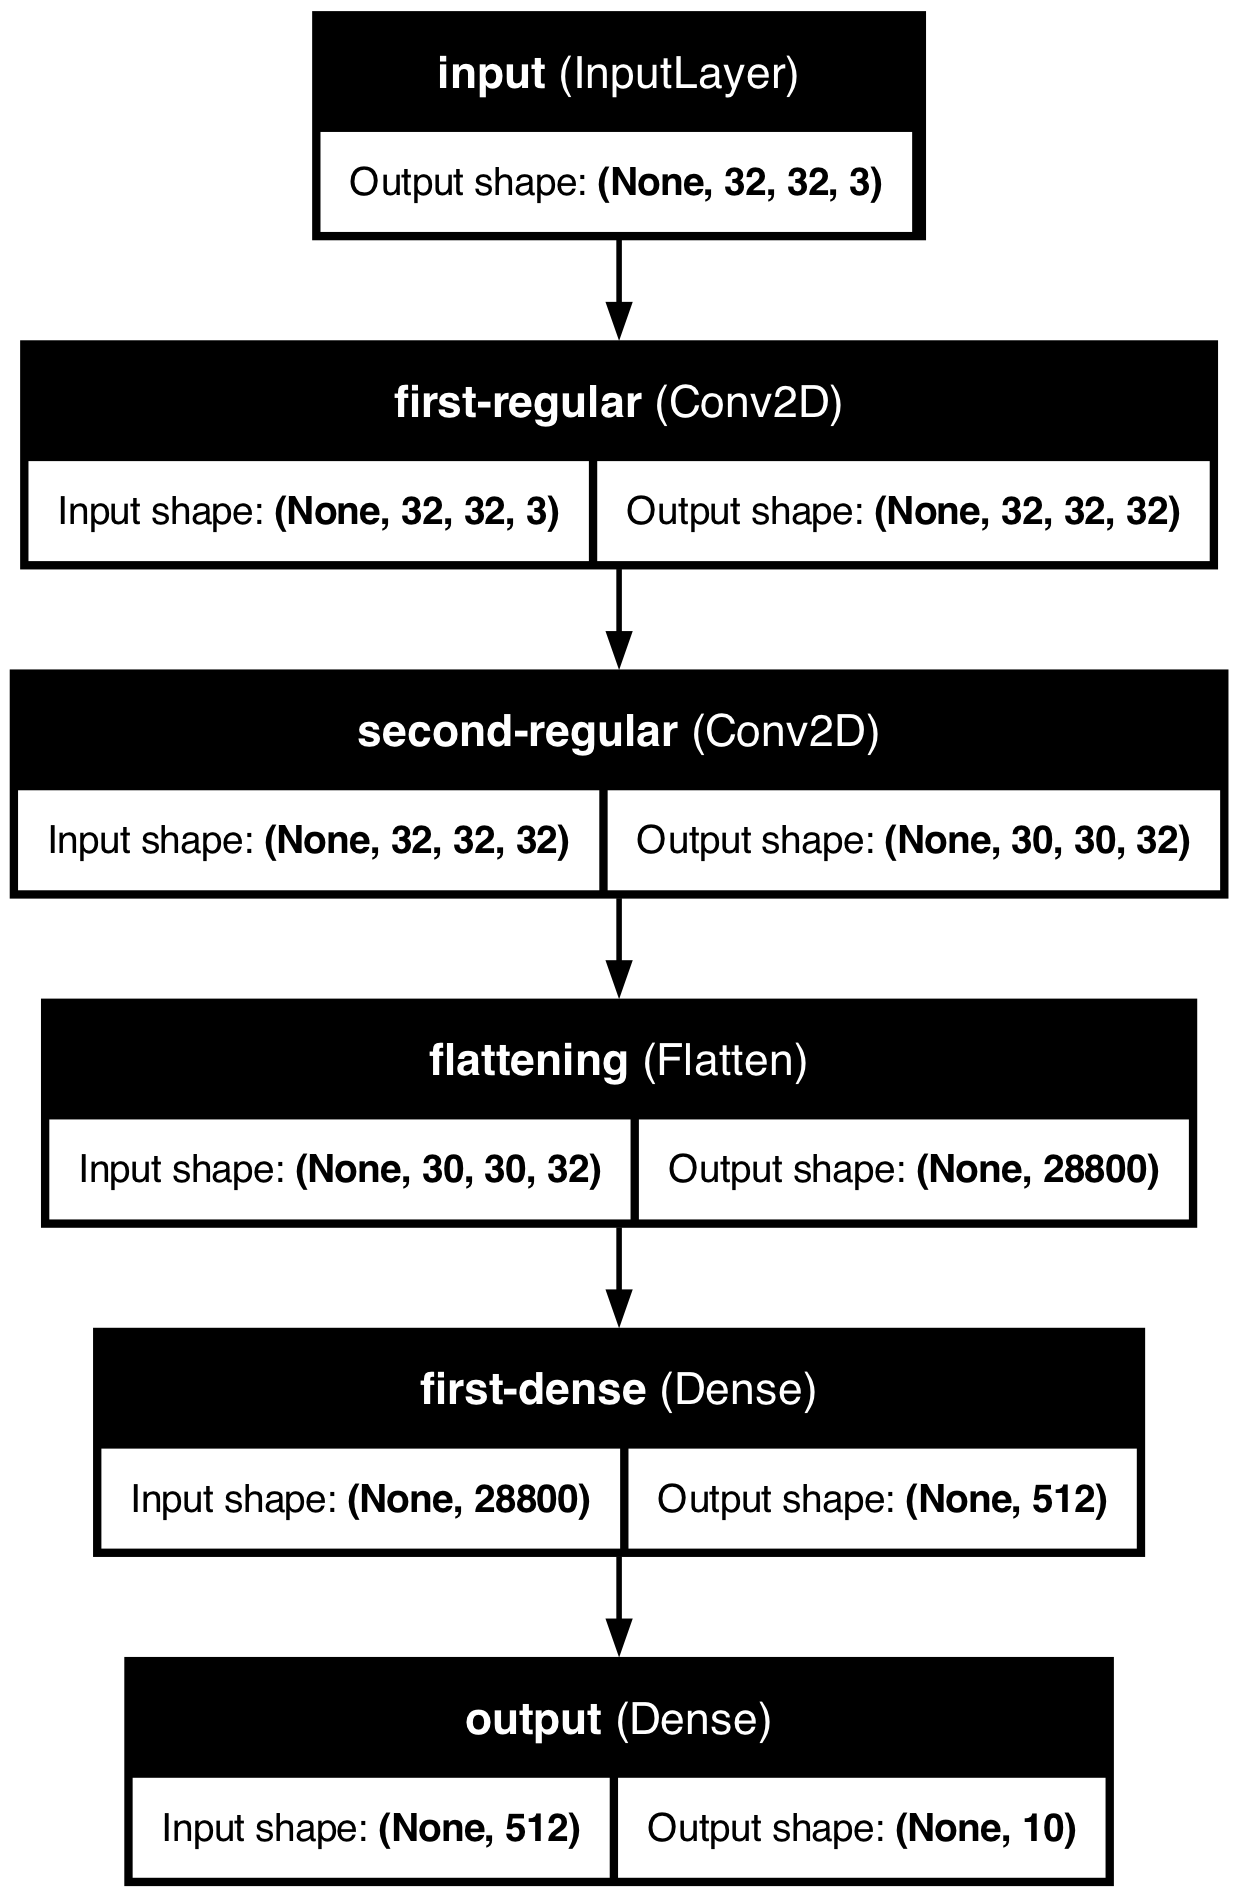

In [80]:
inputs = tf.keras.Input(shape=x_train.shape[1:], name="input")

x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu", name="first-regular")(inputs)
x = tf.keras.layers.Conv2D(32, 3, activation="relu", name="second-regular")(x)

x = tf.keras.layers.Flatten(name="flattening")(x)
x = tf.keras.layers.Dense(512, activation="relu", name="first-dense")(x)

outputs = tf.keras.layers.Dense(num_of_classes, activation="softmax", name="output")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

plot_model(
    model,
    "convolutional_network.png",
    show_shapes=True,
    show_layer_names=True
)

_compile and train model

In [81]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['acc']
)

batch_size = 32
epochs = 50

print(y_test.shape)

history = model.fit(x_train, y_train, batch_size=batch_size,
                    epochs=epochs)

(10000, 1, 10)
Epoch 1/50


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None, 1, 10), output.shape=(None, 10)